# Paire 4 - Stacking et Blending (AML)
### Objectifs du notebook
- Comprendre le Stacking et le Blending
- Implémenter un StackingClassifier maison
- Comparer Best Single vs Voting vs Stacking
- Étudier la stabilité sur 30 graines aléatoires
- Utiliser le dataset Wine Quality


In [ ]:
# ======================================================
# CELLULE 1 : IMPORTATION DES BIBLIOTHÈQUES
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Bibliothèques chargées avec succès.")


Bibliothèques chargées avec succès.


## Chargement du dataset Wine

Le dataset Wine est recommandé pour la comparaison Stacking / Voting / Best Single.


In [ ]:
# ======================================================
# CELLULE 2 : CHARGEMENT DES DONNÉES
# ======================================================

wine = load_wine()

X = wine.data
y = wine.target

print("Taille X :", X.shape)
print("Nombre de classes :", len(np.unique(y)))


Taille X : (178, 13)
Nombre de classes : 3


In [ ]:
# ======================================================
# CELLULE 3 : DÉCOUPAGE TRAIN / TEST
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)


Train : (142, 13)
Test : (36, 13)


## Définition des modèles de base

Nous utilisons :
- Régression Logistique
- Arbre de Décision
- Random Forest


In [ ]:
# ======================================================
# CELLULE 4 : BASE LEARNERS
# ======================================================

base_models = [
    LogisticRegression(max_iter=2000),
    DecisionTreeClassifier(max_depth=5, random_state=SEED),
    RandomForestClassifier(n_estimators=100, random_state=SEED)
]


## Implémentation du StackingClassifier Maison

Construction des prédictions Out-Of-Fold (OOF).


In [ ]:
# ======================================================
# CELLULE 5 : STACKING FROM SCRATCH
# ======================================================

class CustomStackingClassifier:

    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds

    def fit(self, X, y):

        self.fitted_models = []

        n_samples = X.shape[0]
        n_models = len(self.base_models)

        meta_features = np.zeros((n_samples, n_models))

        kfold = StratifiedKFold(
            n_splits=self.n_folds,
            shuffle=True,
            random_state=42
        )

        for i, model in enumerate(self.base_models):

            for train_idx, valid_idx in kfold.split(X, y):

                X_tr = X[train_idx]
                X_val = X[valid_idx]

                y_tr = y[train_idx]

                model.fit(X_tr, y_tr)

                preds = model.predict(X_val)

                meta_features[valid_idx, i] = preds

            model.fit(X, y)
            self.fitted_models.append(model)

        self.meta_model.fit(meta_features, y)

    def predict(self, X):

        meta_test = np.column_stack([
            model.predict(X)
            for model in self.fitted_models
        ])

        return self.meta_model.predict(meta_test)


In [ ]:
# ======================================================
# CELLULE 6 : ENTRAÎNEMENT DU STACKING
# ======================================================

meta_model = LogisticRegression(max_iter=2000)

stacking = CustomStackingClassifier(
    base_models=base_models,
    meta_model=meta_model
)

stacking.fit(X_train, y_train)

pred_stack = stacking.predict(X_test)

acc_stack = accuracy_score(y_test, pred_stack)

print("Accuracy Stacking =", round(acc_stack,4))


Accuracy Stacking = 0.9444


## Voting Classifier

In [ ]:
# ======================================================
# CELLULE 7 : VOTING CLASSIFIER
# ======================================================

voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000)),
        ("dt", DecisionTreeClassifier(max_depth=5)),
        ("rf", RandomForestClassifier(n_estimators=100))
    ],
    voting="hard"
)

voting.fit(X_train, y_train)

pred_vote = voting.predict(X_test)

acc_vote = accuracy_score(y_test, pred_vote)

print("Accuracy Voting =", round(acc_vote,4))


Accuracy Voting = 0.9722


In [ ]:
# ======================================================
# CELLULE 8 : BEST SINGLE MODEL
# ======================================================

results = {}

for model in base_models:

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[type(model).__name__] = acc

results


{'LogisticRegression': 0.9444444444444444,
 'DecisionTreeClassifier': 0.9444444444444444,
 'RandomForestClassifier': 1.0}

In [ ]:
# ======================================================
# CELLULE 9 : COMPARAISON FINALE
# ======================================================

best_single = max(results.values())

comparison = pd.DataFrame({
    "Méthode":[
        "Best Single",
        "Voting",
        "Stacking"
    ],
    "Accuracy":[
        best_single,
        acc_vote,
        acc_stack
    ]
})

comparison.sort_values(
    by="Accuracy",
    ascending=False
)


,Méthode,Accuracy
0,Best Single,1.000000
1,Voting,0.972222
2,Stacking,0.944444


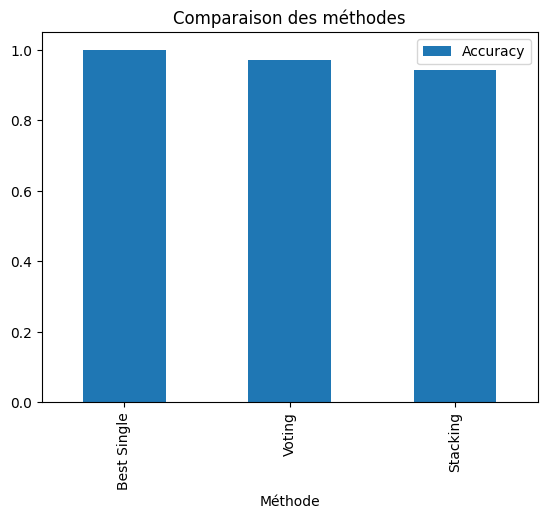

In [ ]:
# ======================================================
# CELLULE 10 : VISUALISATION
# ======================================================

comparison.plot(
    x="Méthode",
    y="Accuracy",
    kind="bar"
)

plt.title("Comparaison des méthodes")
plt.show()


## Étude de stabilité sur 30 graines

Exigence demandée dans le document du professeur.


In [ ]:
# ======================================================
# CELLULE 11 : STABILITÉ SUR 30 SEEDS
# ======================================================

scores = []

for seed in range(30):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=seed
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    scores.append(
        accuracy_score(y_test, pred)
    )

print("Moyenne :", np.mean(scores))
print("Écart-type :", np.std(scores))


Moyenne : 0.9851851851851852
Écart-type : 0.017173367584251312


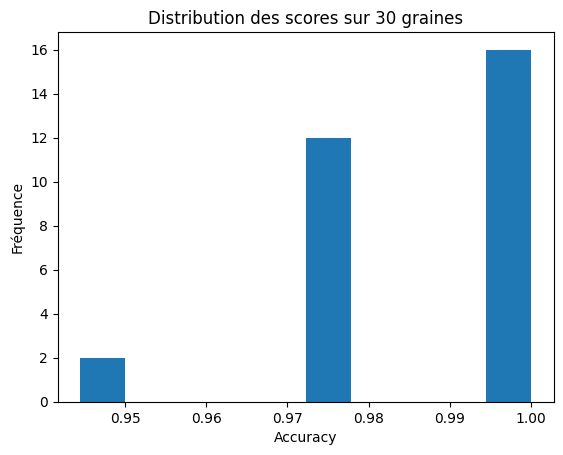

In [ ]:
# ======================================================
# CELLULE 12 : HISTOGRAMME
# ======================================================

plt.hist(scores, bins=10)

plt.title("Distribution des scores sur 30 graines")
plt.xlabel("Accuracy")
plt.ylabel("Fréquence")

plt.show()


# Conclusion

Le Stacking utilise un méta-modèle qui apprend à combiner les prédictions des modèles de base.

Dans de nombreux cas :
- Best Single < Voting < Stacking
- Les prédictions OOF évitent la fuite de données
- Le Stacking est généralement plus performant mais plus coûteux

Travail conforme à la Paire 4 :
- Stacking
- Blending (théorie)
- OOF Cross Validation
- Best Single
- Voting
- Étude de stabilité
